In [ ]:
%pip install cobra

In [9]:
import cobra
import numpy as np
import pandas as pd
from cobra.io import load_model
from cobra.io import load_json_model, save_json_model, load_matlab_model, save_matlab_model, read_sbml_model, write_sbml_model
from cobra import Model, Reaction, Metabolite, Gene
from sklearn.metrics import r2_score  

In [13]:
model = read_sbml_model('C:\\Users\\adam-1y9pxi6q95ggpmx\\Documents\\PhD\\10-19 Research\\11 Data\\11.09_Models\\Manual_curation\\Energy_consumption\\250430_iABA974_nitrogen.sbml')

## NGAM calculation

In [9]:
reaction = model.reactions.get_by_id('EX_co2_e')
reaction.bounds = -100.0, 0.0

reaction = model.reactions.get_by_id('EX_o2_e')
reaction.bounds = -100.0, 0.0

# set reactions bounds for a specific reaction 
reaction = model.reactions.get_by_id('EX_h2_e')
reaction.bounds = -8.7009, -8.7009

In [43]:
reaction = model.reactions.get_by_id('EX_h2_e')
reaction.bounds = -8.7, 1000.0

In [28]:
model.objective = 'ATPM'
solution = model.optimize()
print(f"Flux through ATPM: {solution.objective_value} mmol/gDW/hr")

Flux through ATPM: 38.79999999999999 mmol/gDW/hr


In [30]:
model.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
h2_e,EX_h2_e,19.4,0,0.00%
o2_e,EX_o2_e,9.7,0,0.00%
Metabolite,Reaction,Flux,C-Number,C-Flux
h2o_e,EX_h2o_e,-19.4,0,0.00%


GAM determination

In [4]:
reaction = model.reactions.get_by_id('ATPM')
reaction.bounds = 21.2, 1000.0

In [23]:
model.objective = 'Growth'
solution = model.optimize()
model.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
ca2_e,EX_ca2_e,0.0001784,0,0.00%
cl_e,EX_cl_e,0.0001784,0,0.00%
co2_e,EX_co2_e,1.721,1,100.00%
cobalt2_e,EX_cobalt2_e,8.649E-07,0,0.00%
cu2_e,EX_cu2_e,0.000243,0,0.00%
fe2_e,EX_fe2_e,0.000522,0,0.00%
h2_e,EX_h2_e,15.27,0,0.00%
k_e,EX_k_e,0.006691,0,0.00%
mg2_e,EX_mg2_e,0.0002974,0,0.00%
mn2_e,EX_mn2_e,2.371E-05,0,0.00%


In [72]:
reaction = model.reactions.get_by_id('EX_co2_e')
reaction.bounds = -100.0, 0.0

reaction = model.reactions.get_by_id('EX_o2_e')
reaction.bounds = -100.0, 0.0


In [66]:
list_h2_fluxes=[18,19]
dict_slope={}

for gam in range(1,30):


    GAM_metabolites_1 = {'atp_c': -gam, 'h2o_c': -gam}
    GAM_metabolites_2 = {'adp_c': gam, 'pi_c': gam, 'h_c': gam}

    # Get the biomass reaction
    reaction = model.reactions.get_by_id('Growth')

    # Update the coefficients for GAM_metabolites_1
    for element, new_coefficient in GAM_metabolites_1.items():
        metabolite = model.metabolites.get_by_id(element)
        if metabolite in reaction.metabolites:
            reaction.add_metabolites({metabolite: new_coefficient - reaction.metabolites[metabolite]})
    
    

    # Update the coefficients for GAM_metabolites_2
    for element, new_coefficient in GAM_metabolites_2.items():
        metabolite = model.metabolites.get_by_id(element)
        if metabolite in reaction.metabolites:
            reaction.add_metabolites({metabolite: new_coefficient - reaction.metabolites[metabolite]})
    list_growth=[]

    # set reactions bounds for a specific reaction 
    for fluxe in list_h2_fluxes:
        reaction = model.reactions.get_by_id('EX_h2_e')
        reaction.bounds = -fluxe, 0.0
        model.objective = 'Growth'
        solution = model.slim_optimize()
        list_growth.append(solution)
        print(solution)
    
    dict_slope[gam]=(list_h2_fluxes[0]-list_h2_fluxes[1])/(list_growth[0]-list_growth[1])

print(dict_slope)


0.06914166192587129
0.07376137207682044
0.06892937277712688
0.07353489879787112
0.0687183832423727
0.07330981196681127
0.06850868142386493
0.07308609889093862
0.06830025556863437
0.07286374703202346
0.06809309406630788
0.07264274400392284
0.06788718544695646
0.07242307757036007
0.06768251837895006
0.07220473564258076
0.06747908166691849
0.07198770627718139
0.06727686424967555
0.07177197767392424
0.06707585519824819
0.0715575381736346
0.06687604371386337
0.07134437625599425
0.06667741912606337
0.0711324805376037
0.06647997089076073
0.07092183976987437
0.06628368858840475
0.07071244283707395
0.06608856192213651
0.07050427875435207
0.0658945807159913
0.07029733666583451
0.06570173491312248
0.07009160584273019
0.0655100145740695
0.06988707568146807
0.06531940987505554
0.06968373570189706
0.06512991110629392
0.06948157554546742
0.06494150867035617
0.06928058497349539
0.06475419308054252
0.06908075386543078
0.06456795495928316
0.06888207221714145
0.0643827850365908
0.06868453013925843
0.0641

In [67]:
reaction_id_to_check = 'Growth'
reaction = model.reactions.get_by_id(reaction_id_to_check)
print(f"Reaction ID: {reaction.id}")
print(f"Name: {reaction.name}")
print(f"Equation: {reaction.reaction}")
print(f"Lower Bound: {reaction.lower_bound}")
print(f"Upper Bound: {reaction.upper_bound}")
sum = 0
#reaction.name = '(S)-2-Acetolactate pyruvate-lyase (carboxylating)'
print("\nMetabolites and Stoichiometry:")
for metabolite, coefficient in reaction.metabolites.items():
    print(f"{metabolite.id:<15}: {coefficient:>25}  Name: {metabolite.name:<60}  Charge: {metabolite.charge:>3}  Formula: {metabolite.formula}")
    sum += coefficient * metabolite.charge
print(f'\nSum charge: {sum}')
print("\nAssociated Genes:")
for gene in reaction.genes:
    print(gene.id)

Reaction ID: Growth
Name: Biomass reaction
Equation: 0.000223 10fthf_c + 0.000223 2dmmql8_c + 0.000223 5mthf_c + 0.000279 accoa_c + 0.513689 ala__L_c + 0.000223 amet_c + 0.030016 arab__L_c + 0.295792 arg__L_c + 0.241055 asn__L_c + 0.241055 asp__L_c + 29.0 atp_c + 0.005205 ca2_c + 0.000223 chor_c + 0.005205 cl_c + 0.002944 clpn160_p + 0.00229 clpn161_p + 0.00118 clpn181_p + 0.000576 coa_c + 0.0001 cobalt2_c + 0.133508 ctp_c + 0.000709 cu2_c + 0.09158 cys__L_c + 0.026166 datp_c + 0.027017 dctp_c + 0.027017 dgtp_c + 0.026166 dttp_c + 0.000223 fad_c + 0.006715 fe2_c + 0.007808 fe3_c + 0.644556 fru_c + 0.005772 gal_c + 0.117366841601577 glc__D_c + 0.26316 gln__L_c + 0.26316 glu__L_c + 0.612638 gly_c + 0.215096 gtp_c + 29.0 h2o_c + 0.000223 hemeO_c + 0.049935 hexadecacid_c + 0.007033 hexedecacid_c + 0.094738 his__L_c + 0.290529 ile__L_c + 0.195193 k_c + 0.019456 kdo2lipid4_p + 0.450531 leu__L_c + 0.005903 lnlc_c + 0.000364 lnlncg_c + 0.343161 lys__L_c + 3.1e-05 malcoa_c + 0.00481 man_c + 0.1

## Oxidative Phosphorylation complex addition

In [1]:
# we set an unlimited bound for the limiting substrate
reaction = model.reactions.get_by_id('EX_co2_e')
reaction.bounds = -100.0, 0.0

NameError: name 'model' is not defined

In [ ]:

reaction = model.reactions.get_by_id('EX_o2_e')
reaction.bounds = -6.92, 0.0


Addition of proton translocation to the NADH dehydrogenase reaction


In [ ]:
reaction = model.reactions.get_by_id('NADH5')
metabolite_to_add = 'h_p'
reaction.add_metabolites({metabolite_to_add: 4.0})

print(f"Reaction ID: {reaction.id}")
print(f"Name: {reaction.name}")
print(f"Equation: {reaction.reaction}")
print(f"Lower Bound: {reaction.lower_bound}")
print(f"Upper Bound: {reaction.upper_bound}")
print(reaction.annotation)
print(f"Genes: {[gene.id for gene in reaction.genes]}")


Reaction ID: NADH5
Name: NADH dehydrogenase (ubiquinone-8 )
Equation: 5.0 h_c + nadh_c + q8_c --> 4.0 h_p + nad_c + q8h2_c
Lower Bound: 0.0
Upper Bound: 1000.0
{'sbo': 'SBO:0000176', 'rhea': ['29107', '29108', '29109', '29110'], 'metanetx.reaction': 'MNXR101872', 'seed.reaction': 'rxn08975'}
Genes: ['AAFOLC_07640']


In [ ]:
summary = model.metabolites.get_by_id('h_p').summary()
summary

Percent,Flux,Reaction,Definition
0.00%,3.333E-05,CYTBD2pp,2.0 h_c + mql8_c + 0.5 o2_c --> h2o_c + 2.0 h_p + mqn8_c
33.24%,27.69,CYTBDpp,2.0 h_c + 0.5 o2_c + q8h2_c --> h2o_c + 2.0 h_p + q8_c
66.52%,55.41,NADH5,5.0 h_c + nadh_c + q8_c --> 4.0 h_p + nad_c + q8h2_c
0.23%,0.1951,PLIPA1G160pp,h2o_p + pg160_p --> 2agpg160_p + h_p + hdca_p
Percent,Flux,Reaction,Definition
99.77%,-83.11,ATPS4rpp,adp_c + 4.0 h_p + pi_c <=> atp_c + h2o_c + 3.0 h_c
0.23%,-0.1951,FACOAL160t2pp,atp_c + coa_c + h_p + hdca_p --> amp_c + h_c + pmtcoa_c + ppi_c


In [ ]:
model.slim_optimize()

0.024017630944258673

In [ ]:
model.summary()

Metabolite,Reaction,Flux,C-Number,C-Flux
ca2_e,EX_ca2_e,0.0002507,0,0.00%
cl_e,EX_cl_e,0.0002507,0,0.00%
co2_e,EX_co2_e,2.444,1,100.00%
cobalt2_e,EX_cobalt2_e,4.816E-06,0,0.00%
cu2_e,EX_cu2_e,3.415E-05,0,0.00%
fe2_e,EX_fe2_e,0.0007317,0,0.00%
h2_e,EX_h2_e,18.98,0,0.00%
k_e,EX_k_e,0.009401,0,0.00%
mg2_e,EX_mg2_e,0.0004178,0,0.00%
mn2_e,EX_mn2_e,3.328E-05,0,0.00%


# Setting the GAM value

In [5]:
GAM_metabolites_1 = {'atp_c': -40.0, 'h2o_c': -40.0}
GAM_metabolites_2 = {'adp_c': 40.0, 'pi_c': 40.0, 'h_c': 40.0}

# Get the biomass reaction
reaction = model.reactions.get_by_id('Growth')

# Update the coefficients for GAM_metabolites_1
for element, new_coefficient in GAM_metabolites_1.items():
    metabolite = model.metabolites.get_by_id(element)
    if metabolite in reaction.metabolites:
        print(f'Old coefficient for {element}: {reaction.metabolites[metabolite]}')
        reaction.add_metabolites({metabolite: new_coefficient - reaction.metabolites[metabolite]})
        print(f'Updated {element} coefficient to {new_coefficient}')

# Update the coefficients for GAM_metabolites_2
for element, new_coefficient in GAM_metabolites_2.items():
    metabolite = model.metabolites.get_by_id(element)
    if metabolite in reaction.metabolites:
        print(f'Old coefficient for {element}: {reaction.metabolites[metabolite]}')
        reaction.add_metabolites({metabolite: new_coefficient - reaction.metabolites[metabolite]})
        print(f'Updated {element} coefficient to {new_coefficient}')

# Optimize the model
solution = model.slim_optimize()
print(f'Optimal solution: {solution}')

Old coefficient for atp_c: -75.5
Updated atp_c coefficient to -40.0
Old coefficient for h2o_c: -75.5
Updated h2o_c coefficient to -40.0
Old coefficient for adp_c: 75.5
Updated adp_c coefficient to 40.0
Old coefficient for pi_c: 75.5
Updated pi_c coefficient to 40.0
Old coefficient for h_c: 75.5
Updated h_c coefficient to 40.0
Optimal solution: 0.045785650370645546


Set the NGAM value

In [ ]:
reaction = model.reactions.get_by_id('ATPM')
reaction.bounds = 9.27, 1000.0

# Combining different GAM and NGAM values

In [2]:
#file_path ='C:\\Users\\adam-1y9pxi6q95ggpmx\\Documents\\PhD\\10-19 Research\\11 Data\\11.03 Fluxes values\\plot_data - Copy.xlsx'
file_path ='data/240823_growth_data.xlsx'
excel_data = pd.read_excel(file_path)
excel_data = excel_data.drop([4,5])
excel_data

,Unnamed: 0,dilRate,H2 Flux theoretic,O2 flux theoretic,CO2 flux theoretic
0,0,0.046160,19.489454,6.926103,2.509541
1,1,0.035260,17.380479,6.315240,2.058461
2,2,0.026357,15.628204,5.897692,1.617025
3,3,0.020724,15.387005,6.040324,1.431369


run this to set the functions

In [8]:

def compute_r2_score(excel_data):
    """
    Computes the R² (coefficient of determination) between experimental and simulated growth rates.
    """
    if 'dilRate' not in excel_data.columns or 'growth_rate' not in excel_data.columns:
        raise ValueError("DataFrame must contain 'dilRate' and 'growth_rate' columns.")

    r2_value = r2_score(excel_data['dilRate'], excel_data['growth_rate'])  

    return r2_value

In [4]:

def compute_mean_difference(excel_data):
    """
    Computes the mean absolute difference between experimental and simulated growth rates.

    Parameters:
    - excel_data: Pandas DataFrame containing 'dilRate' (experimental) and 'growth_rate' (simulated).

    Returns:
    - mean_difference: The average absolute difference between experimental and simulated values.
    """
    
    # Ensure columns exist
    if 'dilRate' not in excel_data.columns or 'growth_rate' not in excel_data.columns:
        raise ValueError("DataFrame must contain 'dilRate' and 'growth_rate' columns.")
    
    # Compute absolute difference for each row
    differences = abs(excel_data['dilRate'] - excel_data['growth_rate'])
    # Compute the mean difference
    mean_difference = differences.mean()

    return mean_difference


In [5]:
def compute_growth_rates(model, excel_data):
    """
    Computes growth rates by adjusting H2, O2, and CO2 fluxes in the model and optimizing.

    Parameters:
    - model: COBRApy model object
    - excel_data: Pandas DataFrame containing columns 'H2 Flux theoretic' and 'CO2 flux theoretic'

    Returns:
    - Updated DataFrame with calculated growth rates and model-predicted fluxes.
    """
    model.objective = 'Growth'


    # Add columns for growth rate and modeled fluxes
    excel_data['growth_rate'] = None
    excel_data['H2 Flux model'] = None
    excel_data['O2 Flux model'] = None
    excel_data['CO2 Flux model'] = None

    # Get the exchange reactions
    h2_reaction = model.reactions.get_by_id('EX_h2_e')
    o2_reaction = model.reactions.get_by_id('EX_o2_e')
    co2_reaction = model.reactions.get_by_id('EX_co2_e')

    # Iterate over each row in the DataFrame
    for index, row in excel_data.iterrows():
        
        # Set bounds for H2 flux
        h2_reaction.bounds = (-row['H2 Flux theoretic'], 0.0)

        # Set bounds for O2 flux
        o2_reaction.bounds = (-100, 0.0)

        # Set bounds for CO2 flux
        co2_reaction.bounds = (-row['CO2 flux theoretic'], 0.0)

        # Optimize the model
        solution = model.slim_optimize()
        #print(solution)

        # Store results in DataFrame
        excel_data.at[index, 'growth_rate'] = solution
        excel_data.at[index, 'H2 Flux model'] = h2_reaction.flux
        excel_data.at[index, 'O2 Flux model'] = o2_reaction.flux
        excel_data.at[index, 'CO2 Flux model'] = co2_reaction.flux
    print(excel_data)
    return excel_data

In [6]:
def calculate_difference_for_gam(model, gam_value):
    """
    Updates the Growth-Associated Maintenance (GAM) coefficients in the biomass reaction.
    
    Parameters:
    - model: COBRApy model object
    - gam_value: integer, the new GAM coefficient value

    Returns:
    - solution: The optimized solution after modifying the biomass reaction
    """

    # Define the GAM metabolite changes
    GAM_metabolites_1 = {'atp_c': -gam_value, 'h2o_c': -gam_value}
    GAM_metabolites_2 = {'adp_c': gam_value, 'pi_c': gam_value, 'h_c': gam_value}

    # Get the biomass reaction
    reaction = model.reactions.get_by_id('Growth')

    # Function to update metabolite coefficients in the reaction
    def update_coefficients(metabolites):
        for element, new_coefficient in metabolites.items():
            metabolite = model.metabolites.get_by_id(element)
            if metabolite in reaction.metabolites:
                old_coefficient = reaction.metabolites[metabolite]
                reaction.add_metabolites({metabolite: new_coefficient - old_coefficient})

    # Update coefficients for both metabolite groups
    update_coefficients(GAM_metabolites_1)
    update_coefficients(GAM_metabolites_2)


    compute_growth_rates(model,excel_data)

    mean_diff = compute_mean_difference(excel_data)
    r2_value  = compute_r2_score(excel_data)

    
    return mean_diff,r2_value

In [14]:
# Define the H2 uptake range and step size
h2_range = (8.7, 14.7)  # Start and end values
step_size = 0.1  # Step size for iteration

ngam_values = []  # Store ATPM flux values

# list to store result
results = []

# Iterate over the defined range
for uptake in np.arange(h2_range[0], h2_range[1] + step_size, step_size):
    model_copy = model.copy()
    # Get the reaction
    reaction = model_copy.reactions.get_by_id('EX_h2_e')
    reaction.bounds = (-uptake, 1000.0)  # Set H2 uptake flux
    
    model_copy.objective = 'ATPM'  # Set ATP maintenance as the objective
    solution = model_copy.optimize()  # Optimize model_copy
    
    #ngam_values.append(solution.objective_value)  # Store ATPM values

    reaction = model_copy.reactions.get_by_id('ATPM') 
    reaction.bounds = solution.objective_value, 1000.0 #change ATPM bounds

    print('uptake :',uptake)
    print('flux through atpm ',solution.objective_value)
    for gam_value in np.arange(10,150,10):
        mean_difference, r2_value = calculate_difference_for_gam(model_copy, gam_value)  # Get both values
        print(f"GAM Value: {gam_value}, Mean Difference: {mean_difference}")
        # Store the result in a dictionary
        results.append({
            "H2_uptake": uptake,
            "ATPM_flux": solution.objective_value,
            "GAM_value": gam_value,
            "Mean_Difference": mean_difference,
            "R2_Score": r2_value  # Store the R² score
        })

# Convert results into a Pandas DataFrame
results_df = pd.DataFrame(results)
# Save to an Excel or CSV file for further analysis
#results_df.to_excel("gam_analysis_results.xlsx", index=False)
#results_df.to_csv("gam_analysis_results.csv", index=False)


c:\Users\adam-1y9pxi6q95ggpmx\AppData\Local\anaconda3\Lib\site-packages\cobra\util\solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


uptake : 8.7
flux through atpm  21.2
   Unnamed: 0   dilRate  H2 Flux theoretic  O2 flux theoretic  \
0           0  0.046160          19.489454           6.926103   
1           1  0.035260          17.380479           6.315240   
2           2  0.026357          15.628204           5.897692   
3           3  0.020724          15.387005           6.040324   

   CO2 flux theoretic growth_rate H2 Flux model O2 Flux model CO2 Flux model  
0            2.509541    0.043167    -19.489454     -7.159043      -2.061916  
1            2.058461    0.032926    -17.380479     -6.717995      -1.572737  
2            1.617025    0.024417    -15.628204     -6.351543      -1.166296  
3            1.431369    0.023246    -15.387005     -6.301102      -1.110349  
GAM Value: 10, Mean Difference: 0.0024474238781155783
   Unnamed: 0   dilRate  H2 Flux theoretic  O2 flux theoretic  \
0           0  0.046160          19.489454           6.926103   
1           1  0.035260          17.380479           6.315

c:\Users\adam-1y9pxi6q95ggpmx\AppData\Local\anaconda3\Lib\site-packages\cobra\util\solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


uptake : 8.799999999999999
flux through atpm  21.2
   Unnamed: 0   dilRate  H2 Flux theoretic  O2 flux theoretic  \
0           0  0.046160          19.489454           6.926103   
1           1  0.035260          17.380479           6.315240   
2           2  0.026357          15.628204           5.897692   
3           3  0.020724          15.387005           6.040324   

   CO2 flux theoretic growth_rate H2 Flux model O2 Flux model CO2 Flux model  
0            2.509541    0.043167    -19.489454     -7.159043      -2.061916  
1            2.058461    0.032926    -17.380479     -6.717995      -1.572737  
2            1.617025    0.024417    -15.628204     -6.351543      -1.166296  
3            1.431369    0.023246    -15.387005     -6.301102      -1.110349  
GAM Value: 10, Mean Difference: 0.0024474238781155783
   Unnamed: 0   dilRate  H2 Flux theoretic  O2 flux theoretic  \
0           0  0.046160          19.489454           6.926103   
1           1  0.035260          17.380479  

KeyboardInterrupt: 

In [12]:
# Find the row with the minimum Mean Difference
best_result = results_df.loc[results_df['Mean_Difference'].idxmin()]
best_r2_square = results_df.loc[results_df['R2_Score'].idxmax()]

# Print the best GAM value with lowest mean difference
print("Best GAM Value with Lowest Mean Difference:")
print(best_result)
print("Best GAM Value with highest r2 score:")
print(best_r2_square)

Best GAM Value with Lowest Mean Difference:
H2_uptake          10.600000
ATPM_flux          21.200000
GAM_value          10.000000
Mean_Difference     0.002447
R2_Score            0.933707
Name: 266, dtype: float64
Best GAM Value with highest r2 score:
H2_uptake          10.600000
ATPM_flux          21.200000
GAM_value          10.000000
Mean_Difference     0.002447
R2_Score            0.933707
Name: 266, dtype: float64


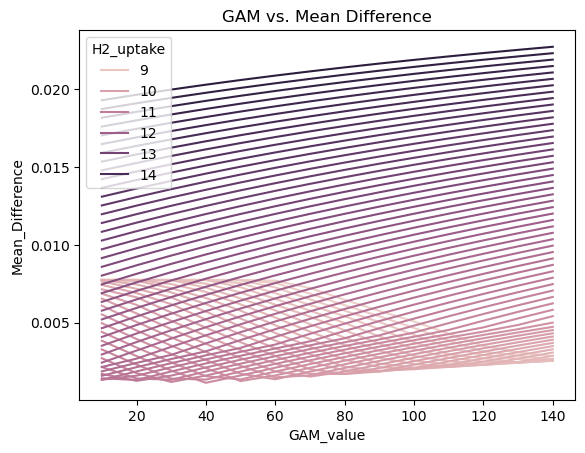

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.lineplot(data=results_df, x='GAM_value', y='Mean_Difference', hue='H2_uptake')
plt.title("GAM vs. Mean Difference")
plt.show()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create a pivot table: rows = H2_uptake, columns = GAM_value, values = R2_Score
heatmap_data = results_df.pivot_table(
    index='ATPM_flux',
    columns='GAM_value',
    values='R2_Score'
)

# Safely round index and columns
heatmap_data.index = heatmap_data.index.to_series().round(1)
heatmap_data.columns = heatmap_data.columns.to_series().round(0)

plt.figure(figsize=(15, 15))

sns.set_style("whitegrid")

# Draw the heatmap
ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.3,
    linecolor='gray',
    cbar_kws={'label': 'R² Score'},
    square=True,
)

# Improve layout and labeling
plt.title("Optimizing GAM and H₂ Uptake via R² Score", fontsize=16, pad=15)
plt.xlabel("GAM Value", fontsize=12)
plt.ylabel("H₂ Uptake", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

TypeError: '>' not supported between instances of 'str' and 'int'

In [ ]:
sbml_filename = "C:\\Users\\adam-1y9pxi6q95ggpmx\\Documents\\PhD\\10-19 Research\\11 Data\\11.09 Models\\Manual_curation\\Energy_consumption\\250317_final_model_1.sbml"
cobra.io.write_sbml_model(model, sbml_filename)